# Example of usage of open_space code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [4]:
from cases.open_space.ngsolve_geometries import AnularDomain

R = 1.
r = 0.2


Lc = 2.
lc = 0.05

mesh = AnularDomain(R=R, r=r, verbosity=0, Lc=Lc, lc=lc)


In [5]:
mesh.n_triangles

222

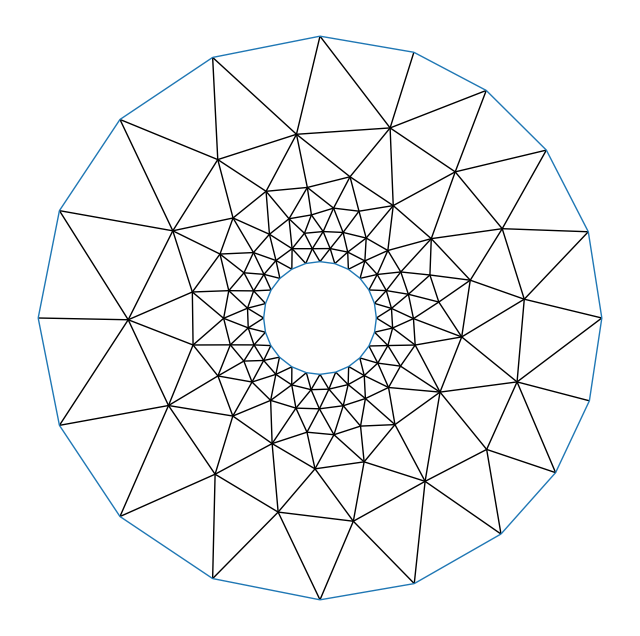

In [6]:
from cases.open_space.plot import plot_openspace
plot_openspace(mesh)

In [7]:
Boundaries = mesh.boundaries
list(Boundaries)

[<Boundaries.SIGMA: 'Sigma'>, <Boundaries.D_OMEGA: 'd_Omega'>]

In [8]:
mesh.curve_boundaries([Boundaries.SIGMA, Boundaries.D_OMEGA], radius=[R,r])
mesh.curved_boundaries


[<Boundaries.SIGMA: 'Sigma'>, <Boundaries.D_OMEGA: 'd_Omega'>]

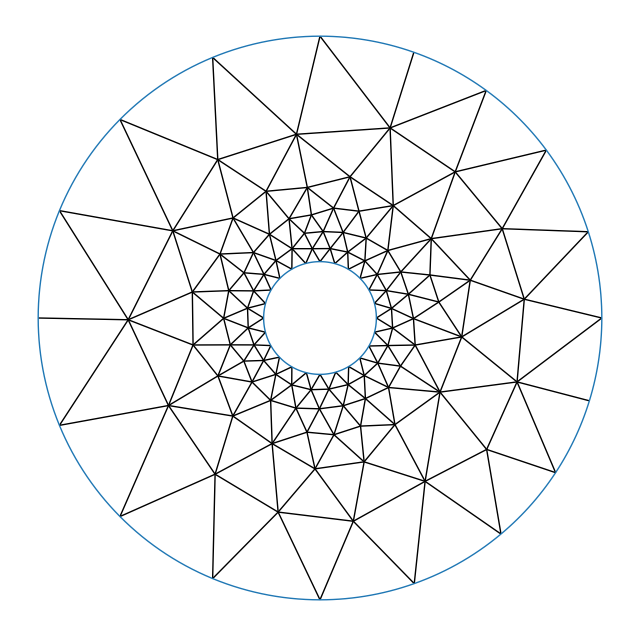

In [9]:
plot_openspace(mesh)

To that regions we can apply different boundary conditions. In our case we will set a radiant boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [10]:
from trefftz.dg.boundary_conditions import NtDBC, DirichletBC

In [11]:
import numpy as np
from trefftz.dg.exact import PlaneWave
data = PlaneWave(d=np.array([-1., 0.]), A=1.)
# boundary_conditions = {Boundaries.SIGMA: NtDBC(truncating_radius=R, data=None), Boundaries.D_OMEGA: DirichletBC(data=data)}
boundary_conditions = {Boundaries.SIGMA: NtDBC(truncating_radius=R, data=data), Boundaries.D_OMEGA: DirichletBC(data=None)}


Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [12]:
# from trefftz.dg.serial_fluxes import UltraWeakFlux, DirichletFlux
from trefftz.dg.block_fluxes import UltraWeakFlux, DirichletFlux


as well as specific ones (for a circular NtD map):

In [13]:
# from cases.open_space.serial_fluxes import NtDLocal, NtDNonLocal
from cases.open_space.block_fluxes import NtDLocal, NtDNonLocal

Now the numerics (the configuration of kernels) is almost a dictionary:

In [14]:
from trefftz.dg.assemblers import BlockNumerics
NtD_modes = 15
a = 0.5
b = 0.5
d2 = 0.5

# numerics = BlockNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
#                           local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=data), NtDBC: NtDLocal(d_2=d2, NtD_modes=NtD_modes, data=None)},
#                           nonlocal_boundary_kernels={NtDBC: NtDNonLocal(d_2=d2, NtD_modes=NtD_modes, data = None)})

numerics = BlockNumerics(interior_kernel=UltraWeakFlux(a=a, b=b),
                          local_boundary_kernels={DirichletBC: DirichletFlux(a=a, data=None), NtDBC: NtDLocal(d_2=d2, NtD_modes=NtD_modes, data=data)},
                          nonlocal_boundary_kernels={NtDBC: NtDNonLocal(d_2=d2, NtD_modes=NtD_modes, data = data)})

We should also choose a local basis

In [15]:
from trefftz.dg.basis import LinearlySpacedBasis
from trefftz.dg.parameters import Elementwise

Regions = mesh.regions


refractive_index = Elementwise(mesh, {Regions.BACKGROUND: 1., Regions.OMEGA : 1.})
k = 8.0
Ntheta = 14
basis = LinearlySpacedBasis(N_elements=mesh.n_triangles, refractive_index=refractive_index, k=k, N_theta=Ntheta)

and an assembler:

In [16]:
basis.N_DOF

3108

In [17]:
from trefftz.dg.assemblers import BlockAssembler

assembler = BlockAssembler(mesh=mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

In [18]:
assembler._regions_RHS_term

[<Boundaries.SIGMA: 'Sigma'>]

so we can set the problem:

In [19]:
from trefftz.problem import Problem
P = Problem(mesh=mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler, direct_solver=True)

In [20]:
P.assemble_LHS()

assembling local operators
region: Sigma


100%|██████████| 18/18 [00:00<00:00, 23.61edge/s]


region: d_Omega


Interior: 100%|██████████| 312/312 [00:00<00:00, 1257.71edge/s]


assembling non-local operators


NtD, Sigma: 100%|██████████| 18/18 [01:53<00:00,  6.31s/edge]


<COOrdinate sparse array of dtype 'complex128'
	with 316344 stored elements and shape (3108, 3108)>

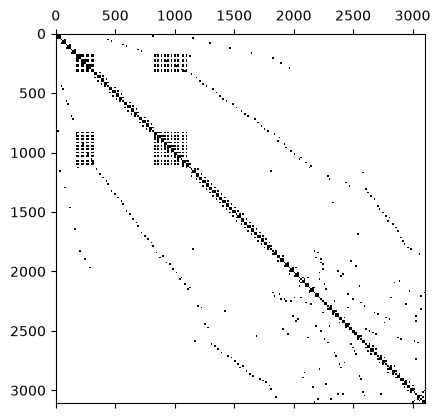

In [21]:
import matplotlib.pyplot as plt 
plt.spy(P.A.toarray())

In [22]:
P.assemble_RHS()

array([0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j], shape=(3108,))

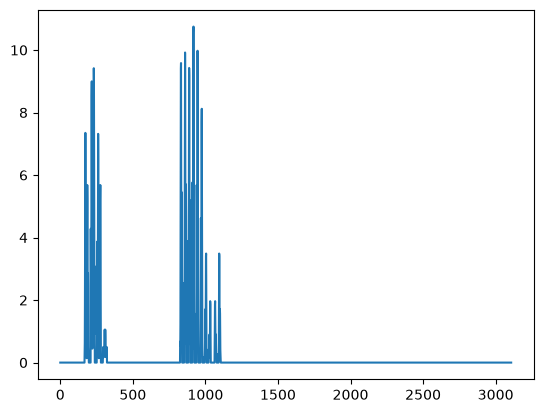

In [23]:
import numpy as np 
plt.plot(np.abs(P.b))

In [24]:
P.solve()

In [25]:
P.u_h.coefficients.reshape((-1,Ntheta))

array([[-3.55174344e+04+7.57241695e+03j,  3.40012052e+04+2.01844394e+04j,
        -1.61856817e+04-3.72879612e+04j, ...,
        -5.54550029e+03-1.96213246e+04j, -1.83809968e+03+2.57200626e+04j,
         1.88158158e+04-2.52303892e+04j],
       [-1.94797946e+03+1.86250055e+03j,  6.02939457e+02-4.79856036e+03j,
        -3.57253141e+03+8.18151471e+03j, ...,
        -1.86300304e+03-1.13735823e+04j, -2.29569366e+03+9.67838790e+03j,
         4.55864029e+03-4.59809840e+03j],
       [ 1.67630783e+04+4.98001395e+03j, -7.63278811e+03-1.52116165e+04j,
        -2.90732043e+03+1.47819672e+04j, ...,
        -7.51220680e+02+1.04137026e+04j,  5.47086616e+03-1.27201550e+04j,
        -1.41726274e+04+8.17323974e+03j],
       ...,
       [ 6.17825948e-01+7.18143461e-01j,  1.15443845e+00-1.81229724e-02j,
         4.89792799e-01-1.37301460e+00j, ...,
         8.05011520e-01+1.59879214e+00j, -4.15360820e-01-9.59082373e-01j,
        -4.00305682e-01+8.58295010e-01j],
       [-2.87619447e+01-3.45323539e+01j, -3.

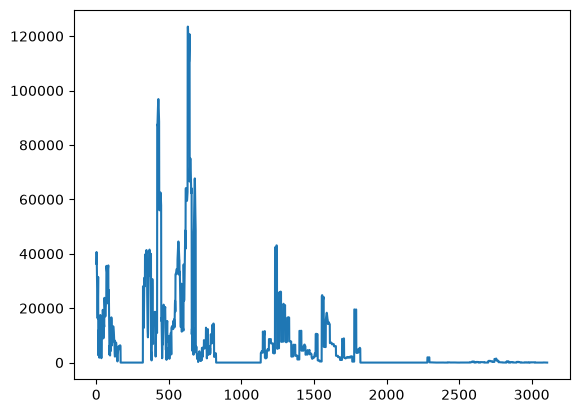

In [26]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

(np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0))

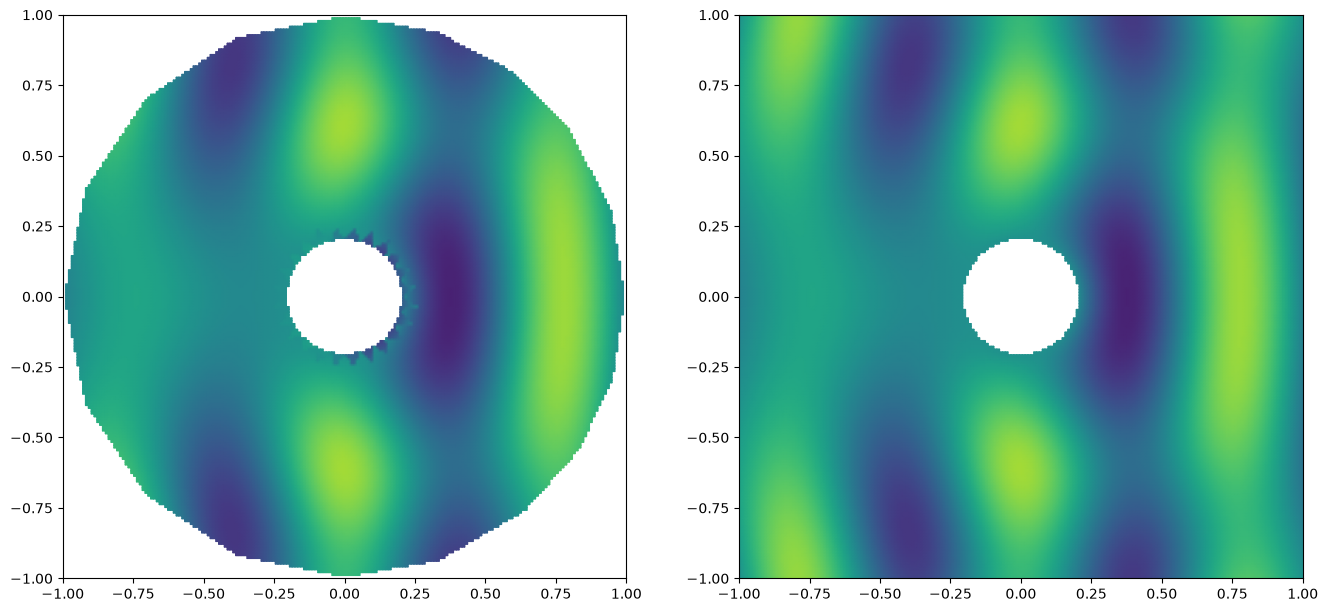

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from cases.open_space.exact import CircularDirichlet

N = 200
x = np.linspace(-R, R, N)
y = np.linspace(-R, R, N)

X, Y = np.meshgrid(x,y)

U_h = P.u_h(X, Y)
U_s = CircularDirichlet(X, Y, R=r, k=k, theta_inc=np.pi)
U_inc = np.exp(-1j*k*X)
U = U_s + U_inc
fig, ax = plt.subplots(ncols=2, figsize=(16,8))
vmin = np.min(U.real)
vmax = np.max(U.real)


ax[0].pcolormesh(X, Y, np.real(U_h), vmin=-2, vmax=2, shading="gouraud")
ax[0].axis('square')
# ax[1].pcolormesh(X, Y, np.real(Z_exact), vmin=-1, vmax=1, shading="gouraud")
# ax[1].axis('square')

ax[1].pcolormesh(X, Y, np.real(U), vmin=-2, vmax=2, shading="gouraud")
ax[1].axis('square')


(np.float64(-1.0), np.float64(1.0), np.float64(-1.0), np.float64(1.0))

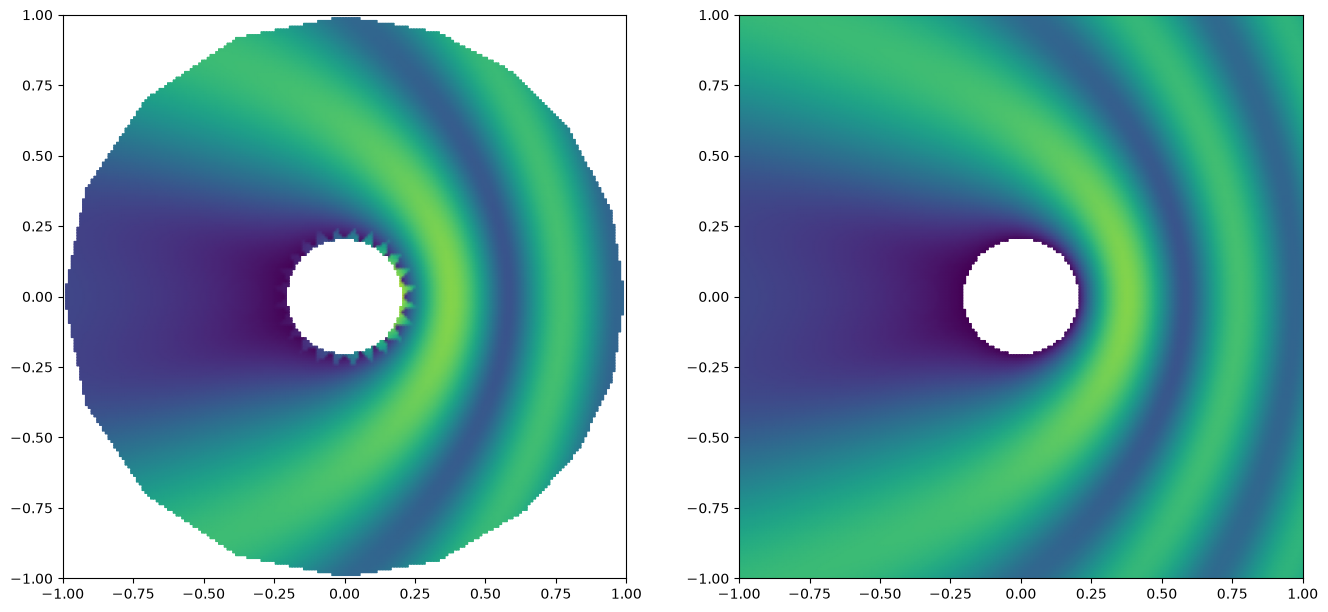

In [28]:
fig, ax = plt.subplots(ncols=2, figsize=(16,8))

ax[0].pcolormesh(X, Y, np.abs(U_h), vmin=0, vmax=2, shading="gouraud")
ax[0].axis('square')

ax[1].pcolormesh(X, Y, np.abs(U), vmin=0, vmax=2, shading="gouraud")
ax[1].axis('square')


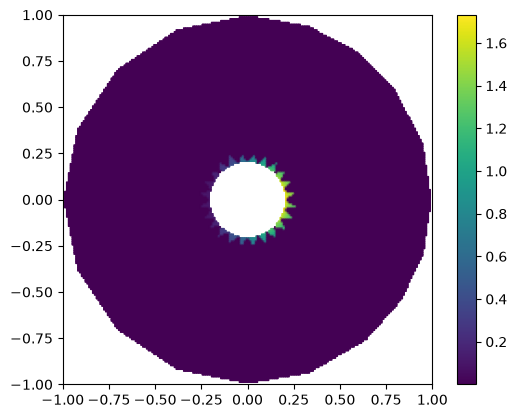

In [29]:
plt.pcolormesh(X, Y, np.abs(U - U_h), shading="gouraud")
plt.axis("square")
plt.colorbar()